### Assignment 11: Matplotlib (Core Plot Types & Visualization)

- Problem Statement
i am working as a Data Analyst trainee. The analytics team wants me to visualize different types of data using Matplotlib. My task is to create clear and correct plots for various real-world scenarios using Matplotlib's core plotting functions.

Sales Dataset from kaggle i am using for completing Assignment -> 
"https://www.kaggle.com/datasets/syedanwarafridi/vehicle-sales-data"


In [1]:
import pandas as pd

# Loads dataset
# Since it is in same folder, no path prefix used is needed
try:
    df_car_sales = pd.read_csv('car_prices.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df_car_sales.shape}")
except FileNotFoundError:
    print("Error: 'car_prices.csv' not found in current directory.")
    import os
    print("Files in current directory:", os.listdir())

# Display first 5 rows
df_car_sales.head()


Dataset loaded successfully!
Shape: (558837, 16)


,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,SUV,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,BMW,3 Series,328i SULEV,Sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,Sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,BMW,6 Series Gran Coupe,650i,Sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [2]:
import logging

# will use it appropiately now not repeat mistake of using logger excessively at every point
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filename='assignment.log',
    filemode='a'
)
console = logging.StreamHandler()
console.setLevel(logging.INFO)
logging.getLogger('').addHandler(console)

logger = logging.getLogger(__name__)

### General overview 
- I will try to form a report for fullfilling requirements of car dealer who have to take care of inventory. 
- under guidelines, I will try to create insights of sales such that car dealer use it to know pattern of sales and fill inventory accordingly. 

### Task 1 Line Plot (Sales Trend for months)
- This plot reveals Seasonality of Demand. For a seller, it identifies Golden Months where buyer activity peaks. If the line trends upward in specific months. it signals the time to release Premium inventory to capture higher prices. Vice Versa, if dips in line suggest periods where car dealer should offer discounts or hold inventory to avoid selling in a cold market.

C:\Users\Dhruv\AppData\Local\Temp\ipykernel_5856\1855511340.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_car_sales['saledate'] = pd.to_datetime(df_car_sales['saledate'], utc=True, errors='coerce')
C:\Users\Dhruv\AppData\Local\Temp\ipykernel_5856\1855511340.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_car_sales['month_year'] = df_car_sales['saledate'].dt.to_period('M')
Data aggregation for sales trend completed.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plottin

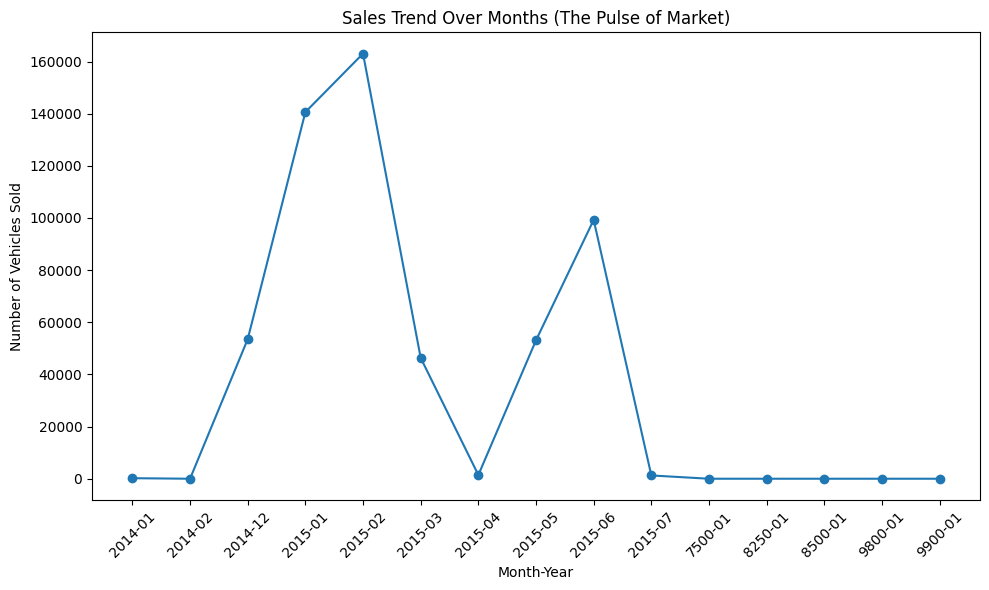

Task 1: Line Plot completed successfully.


In [3]:
import matplotlib.pyplot as plt

#  DATA PREPARATION STAGE

# Convert saledate to datetime object;
df_car_sales['saledate'] = pd.to_datetime(df_car_sales['saledate'], utc=True, errors='coerce')

# Extract month and year;
df_car_sales['month_year'] = df_car_sales['saledate'].dt.to_period('M')

# Aggregate sales data; Group by month_year and counting occurrences
monthly_sales = df_car_sales.groupby('month_year').size()
logger.info("Data aggregation for sales trend completed.")

# TASK 1 - LINE PLOT (SALES TREND) 

# Convert period index to string; Matplotlib requires string or datetime objects for x-axis labels
x_axis = monthly_sales.index.astype(str)
y_axis = monthly_sales.values

# Calling plt.figure with appropiate dimensions
plt.figure(figsize=(10, 6))

# Create line plot; To visualize "Pulse of Market" and identify Golden Months;
plt.plot(x_axis, y_axis, marker='o', linestyle='-')

# Add plot metadata;
plt.title('Sales Trend Over Months (The Pulse of Market)')
plt.xlabel('Month-Year')
plt.ylabel('Number of Vehicles Sold')

# Rotate x-axis labels; To prevent overlapping of date strings;
plt.xticks(rotation=45)

# VALIDATION & DISPLAY

# Display final plot;
plt.tight_layout()
plt.show()

logger.info("Task 1: Line Plot completed successfully.")

### Task 2 : Scatter Plot() 
- This is Performance Audit. By plotting Manufacture Markup Retail (MMR) against actual Selling Price, Car dealer will see Truth of Transaction. Points clustering above diagonal line represent your Wins vehicles where sales tactics or vehicle prep yielded a premium over market expectations. Points below the line are "Red Flags," indicating either over-valuation at purchase or a failure to realize the vehicle's estimated worth.

Data cleaned for Scatter Plot. Total records: 558799


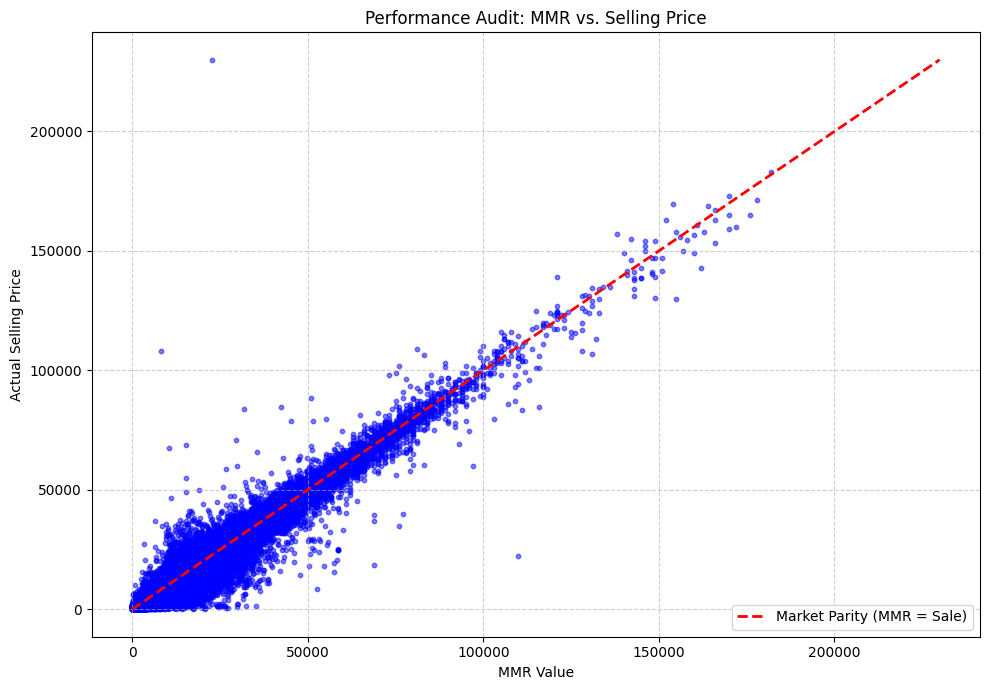

Task 2: Scatter Plot completed successfully.


In [4]:
# Filter out missing values; although dataset description on kaggle already suggested no missing values
df_clean = df_car_sales.dropna(subset=['mmr', 'sellingprice'])
logger.info(f"Data cleaned for Scatter Plot. Total records: {len(df_clean)}")

# Define data for axes; compare predicted market value (MMR) against actual realized value (Selling Price);
x_values = df_clean['mmr']
y_values = df_clean['sellingprice']

#  scatter plot; To identify Wins(above diagonal) and Red Flags(below diagonal);
plt.figure(figsize=(10, 7))
plt.scatter(x_values, y_values, alpha=0.5, color='blue', s=10)

# Add plot annotations; provide context for Car Dealer's Performance Audit; 
plt.title('Performance Audit: MMR vs. Selling Price')
plt.xlabel('MMR Value')
plt.ylabel('Actual Selling Price')
# Add a 45-degree diagonal reference line;
limit_val = max(df_clean['mmr'].max(), df_clean['sellingprice'].max())
plt.plot([0, limit_val], [0, limit_val], color='red', linestyle='--', linewidth=2, label='Market Parity (MMR = Sale)')


# Add grid so dealer estimate distance of points from market average;
plt.grid(True, linestyle='--', alpha=0.6)

# Finalize and display the plot;
plt.tight_layout()
plt.legend()
plt.show()

logger.info("Task 2: Scatter Plot completed successfully.")

### Task 3: Bar Plot() [Horizontal & Vertical]

This plot identifies Inventory Velocity. The tallest bars in the vertical chart represent Safe Bets brands like Kia or BMW that have high consumer trust and move quickly. The horizontal chart for body types (SUVs vs. Sedans) tells you what Current Lifestyle Trend is. for car seller, this helps to decide what to bid on at auctions to ensure your capital isn't tied up in slow-moving stock

Top brands identified: ['Ford', 'Chevrolet', 'Nissan', 'Toyota', 'Dodge', 'Honda', 'Hyundai', 'BMW', 'Kia', 'Chrysler']
Top body types identified: ['Sedan', 'SUV', 'sedan', 'suv', 'Hatchback', 'Minivan', 'Coupe', 'Wagon', 'Crew Cab', 'Convertible']
Vertical bar chart for Brand Liquidity generated.


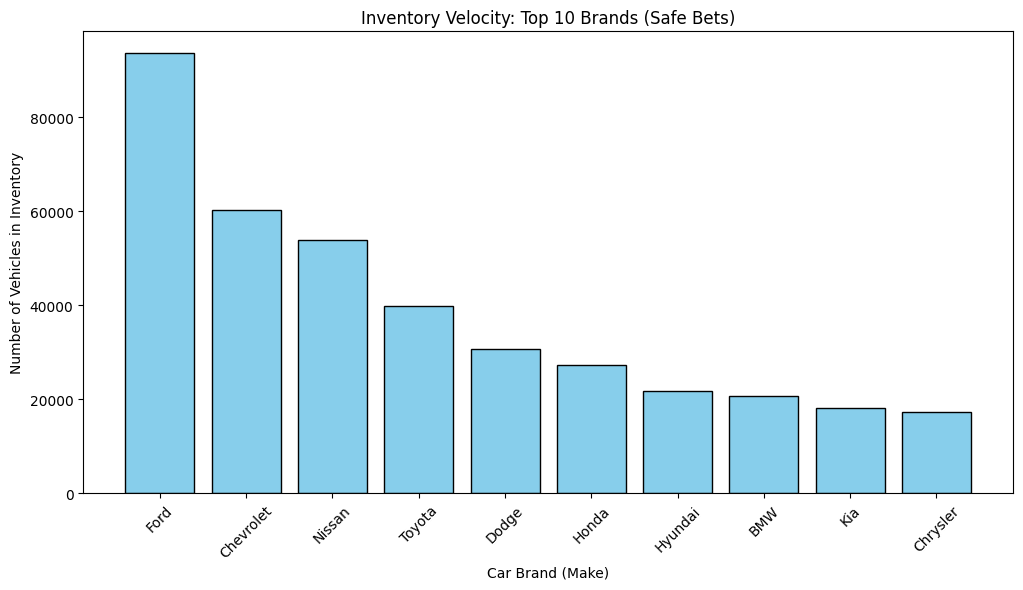

Horizontal bar chart for Lifestyle Trends generated.


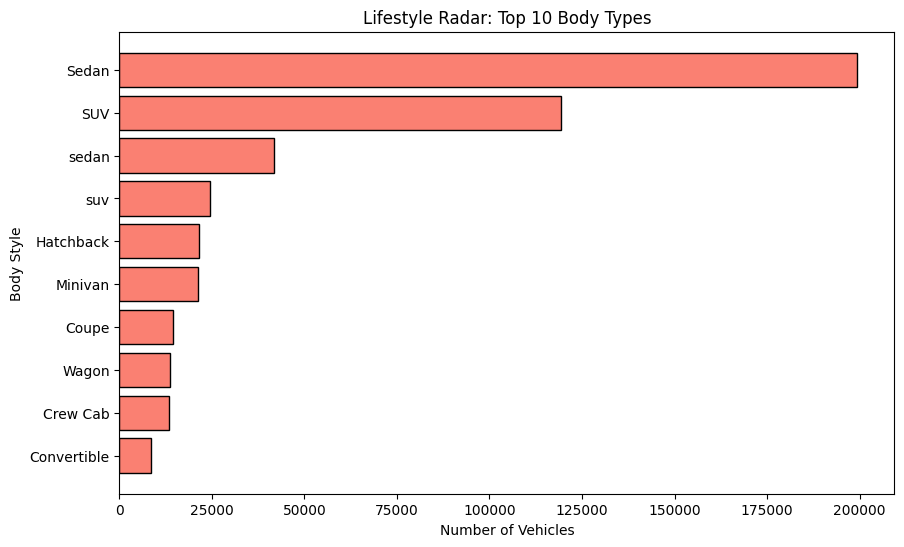

Task 3: Bar Plots completed successfully.


In [5]:
# Aggregate frequency of car makes and body types; To identify which categories have highest inventory volume (liquidity); 
brand_counts = df_car_sales['make'].value_counts().head(10)
body_counts = df_car_sales['body'].value_counts().head(10)

logger.info(f"Top brands identified: {brand_counts.index.tolist()}")
logger.info(f"Top body types identified: {body_counts.index.tolist()}")

# Create a vertical bar chart for Brands;using brand names on X and counts on Y
plt.figure(figsize=(12, 6))
plt.bar(brand_counts.index, brand_counts.values, color='skyblue', edgecolor='black')
# Add labels and title; 
plt.title('Inventory Velocity: Top 10 Brands (Safe Bets)')
plt.xlabel('Car Brand (Make)')
plt.ylabel('Number of Vehicles in Inventory')
plt.xticks(rotation=45)

logger.info("Vertical bar chart for Brand Liquidity generated.")
plt.show()

# Create a horizontal bar chart for Body Types; To identify "Current Lifestyle Trends" eg :- current trend :shitty wannabe suv (crossovers) or suv;
plt.figure(figsize=(10, 6))
plt.barh(body_counts.index, body_counts.values, color='salmon', edgecolor='black')

# Add labels and invert Y-axis;
plt.title('Lifestyle Radar: Top 10 Body Types')
plt.xlabel('Number of Vehicles')
plt.ylabel('Body Style')
plt.gca().invert_yaxis() 

logger.info("Horizontal bar chart for Lifestyle Trends generated.")
plt.show()

logger.info("Task 3: Bar Plots completed successfully.")


### Task 4 Multiple Bar Plot 
- This tells the story of Brand Resilience. By comparing 2014 and 2015 models, you see which manufacturers successfully "upgraded" their value. If a 2015 BMW shows a massive price jump over the 2014 model compared to a Kia, it tells you that the market perceives a significant leap in quality or tech for that brand. It helps Car Dealer to decide if paying more for a newer model year will actually Converted to a higher profit.

Update -> result came out not as expected  

data prepared for brands: ['Ford', 'Chevrolet', 'Kia', 'Dodge', 'Nissan']
Multiple bar plot construction for Brand Resilience completed.


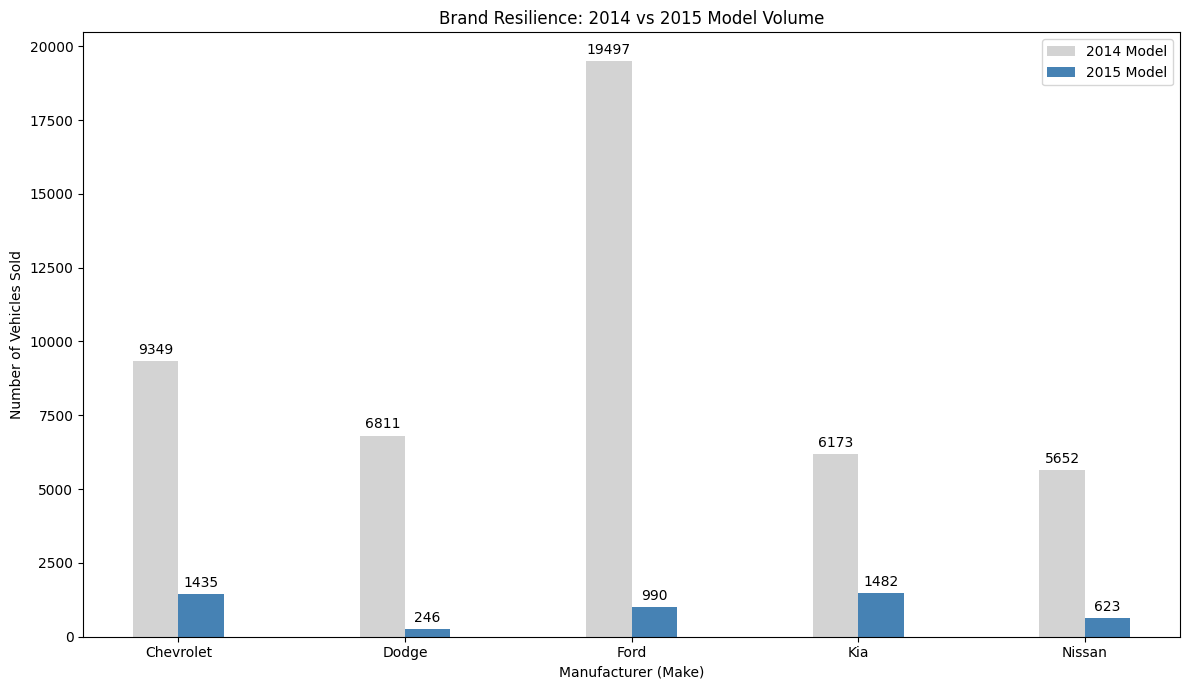

Task 4: Multiple Bar Plot completed successfully.


In [6]:
import numpy as np
# DATA FILTERATION & PREPARATION

# Filter dataset for specific model years;
df_resilience = df_car_sales[df_car_sales['year'].isin([2014, 2015])]

# Select top 5 brands by total volume and filtering dataframe
top_brands = df_resilience['make'].value_counts().head(5).index
df_top_resilience = df_resilience[df_resilience['make'].isin(top_brands)]

# Create a pivot-style count table; Using a manual grouping or a pivot table (without using .plot())
pivot_data = df_top_resilience.groupby(['make', 'year']).size().unstack(fill_value=0)

logger.info(f"data prepared for brands: {list(top_brands)}")

# TASK 4: MULTIPLE BAR PLOT (BRAND RESILIENCE)
# To manually align two bars (2014 and 2015) side-by-side for each brand;
labels = pivot_data.index
x = np.arange(len(labels)) 
width = 0.20

fig, ax = plt.subplots(figsize=(12, 7))

# Plot the first set of bars (2014); Offsetting the X position by -width/2
rects1 = ax.bar(x - width/2, pivot_data[2014], width, label='2014 Model', color='lightgray')

# Plot the second set of bars (2015); Offsetting the X position by +width/2
rects2 = ax.bar(x + width/2, pivot_data[2015], width, label='2015 Model', color='steelblue')

# Add plot metadata 
ax.set_title('Brand Resilience: 2014 vs 2015 Model Volume')
ax.set_ylabel('Number of Vehicles Sold')
ax.set_xlabel('Manufacturer (Make)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

logger.info("Multiple bar plot construction for Brand Resilience completed.")

# RESULTS RENDER
# Add value labels on top of bars; Iterating through the bar containers and using ax.bar_label
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

# Display the final visualization; To finalize the "Brand Resilience" report; Calling plt.show()
plt.tight_layout()
plt.show()
logger.info("Task 4: Multiple Bar Plot completed successfully.")

### TASK 5: Stacked Bar Plot()
This visualizes Value Erosion. It shows how Condition of a car acts as Price Decider. Car Dealer might see that Condition -> 5.0 cars dominate Luxury bracket, but as condition drops, the cars are forced into the Budget stack regardless of their Make or Model. For a seller, this justifies that if repairs and improving condition cost and hence cleanliness moves a car up the value chain. 

Data successfully binned into 3 Price Brackets and 3 Condition Ranges.
Stacked bar chart construction for Value Erosion completed.


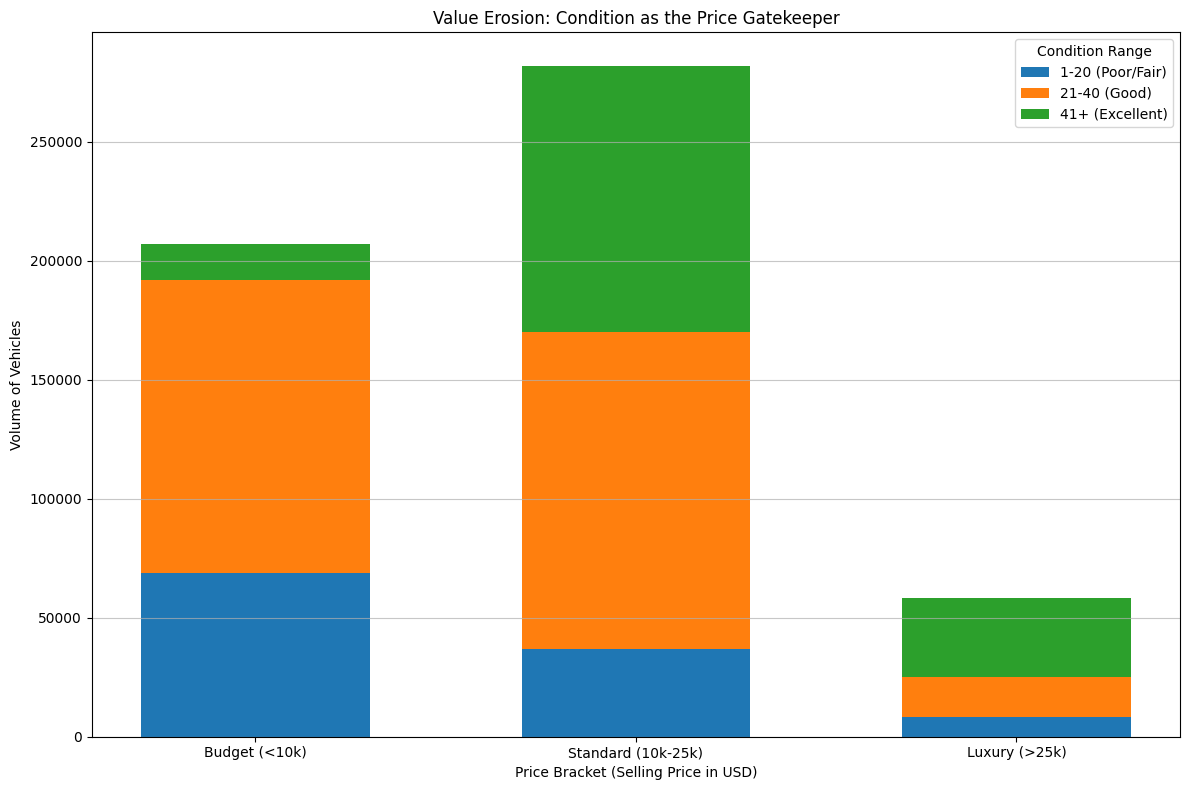

Task 5: Stacked Bar Chart (Revised Ranges) completed successfully.


In [7]:
# DATA PREPROCESSING
# Price Brackets: Budget (<10,000), Standard (10,000-25,000), Luxury (>25,000)
price_bins = [0, 10000, 25000, float('inf')]
price_labels = ['Budget (<10k)', 'Standard (10k-25k)', 'Luxury (>25k)']

# Condition Ranges: 0-20, 20-40, 40-max
max_cond = df_car_sales['condition'].max()
cond_bins = [0, 20, 40, max_cond]
cond_labels = ['1-20 (Poor/Fair)', '21-40 (Good)', '41+ (Excellent)']

# Apply binning to dataframe; To create the dimensions needed for a stacked frequency count;
df_car_sales['price_bracket'] = pd.cut(df_car_sales['sellingprice'], bins=price_bins, labels=price_labels)
df_car_sales['cond_range'] = pd.cut(df_car_sales['condition'], bins=cond_bins, labels=cond_labels)

# Create a cross-tabulation matrix; To calculate the volume of cars per condition tier within each price bracket; -> AI helped
stacked_data = pd.crosstab(df_car_sales['price_bracket'], df_car_sales['cond_range'])

logger.info("Data successfully binned into 3 Price Brackets and 3 Condition Ranges.")

# TASK 5 STACKED BAR PLOT
# Initialize the figure and bar parameters; 
plt.figure(figsize=(12, 8))
categories = stacked_data.index
bottom_tracker = np.zeros(len(categories))

# Iterate through condition ranges to stack bars; Matplotlib requires manual addition of bottom parameter to stack data layers; 
# Looping through cond_labels and updating the bottom_tracker
for i, label in enumerate(cond_labels):
    if label in stacked_data.columns:
        values = stacked_data[label].values
        plt.bar(categories, values, bottom=bottom_tracker, label=label, width=0.6)
        bottom_tracker += values

# Add descriptive metadata; 
plt.title('Value Erosion: Condition as the Price Gatekeeper')
plt.xlabel('Price Bracket (Selling Price in USD)')
plt.ylabel('Volume of Vehicles')
plt.legend(title='Condition Range', loc='upper right')

logger.info("Stacked bar chart construction for Value Erosion completed.")

# RESULTS
# Add gridlines for readability; 
plt.grid(axis='y', alpha=0.7)

plt.tight_layout()
plt.show()

logger.info("Task 5: Stacked Bar Chart (Revised Ranges) completed successfully.")

### TASK 6 HISTOGRAM (MARKS DISTRIBUTION)
This identifies the Mass Market Equilibrium. Peak of histogram shows exact price point where highest volume of buyers exists. As a Car Dealer, if inventory is priced at the tail of the histogram (very high or very low), then it caters in a niche market. This plot tells where to price "Volume Drivers" to ensure they sell within days rather than months.

In [8]:
# DATA PREPROCESSING

# Filter and clean the price data; ensuring histogram reflects actual transactions without null errors; -> although not present as description of data says
price_data = df_car_sales['sellingprice'].dropna()

# Define binning strategy; To find Sweet Spot of buyer volume without over-smoothing or cluttering the distribution;
num_bins = 40
logger.info(f"Data prepared for Histogram. Range: {price_data.min()} to {price_data.max()}. Bins: {num_bins}")

Data prepared for Histogram. Range: 1.0 to 230000.0. Bins: 40


Histogram construction completed. Peak identified at approximately USD 5750.


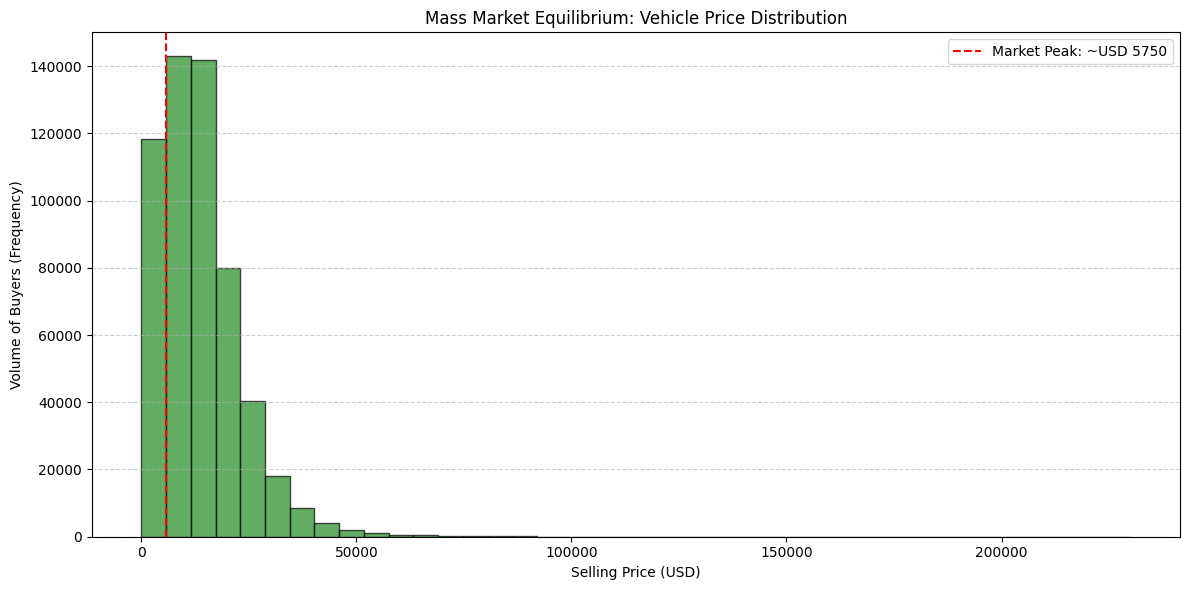

Task 6: Histogram completed successfully


In [9]:
# TASK 6 HISTOGRAM (MASS MARKET EQUILIBRIUM)
# Initialize the figure; 
plt.figure(figsize=(12, 6))

# Create the Histogram; : Using plt.hist with  price data and specified bins
n, bins, patches = plt.hist(price_data, bins=num_bins, color='forestgreen', edgecolor='black', alpha=0.7)

# Add MetaData;
plt.title('Mass Market Equilibrium: Vehicle Price Distribution')
plt.xlabel('Selling Price (USD)')
plt.ylabel('Volume of Buyers (Frequency)')

# Identify the peak price range; Finding the bin with the maximum frequency
max_freq_bin = bins[n.argmax()]
plt.axvline(max_freq_bin, color='red', linestyle='--', label=f'Market Peak: ~USD {int(max_freq_bin)}')
plt.legend()

logger.info(f"Histogram construction completed. Peak identified at approximately USD {int(max_freq_bin)}.")

# Add a grid to the Y-axis;
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Display the final visualization;
plt.tight_layout()
plt.show()

logger.info("Task 6: Histogram completed successfully")


### TASK 7: PIE CHART (Market Share)
- This is a story of Strategic Asset Allocation. It shows how much of Car Dealer's revenue should be utilised on specific brands. by getting information of total share of each brand's by no of vehicle sold of brand's / Total sales. A Car Dealer will get idea of on which brand is safe bet. 

Market share data prepared. Top brand: Ford with 93554 units.
Pie chart construction for Portfolio Risk completed.


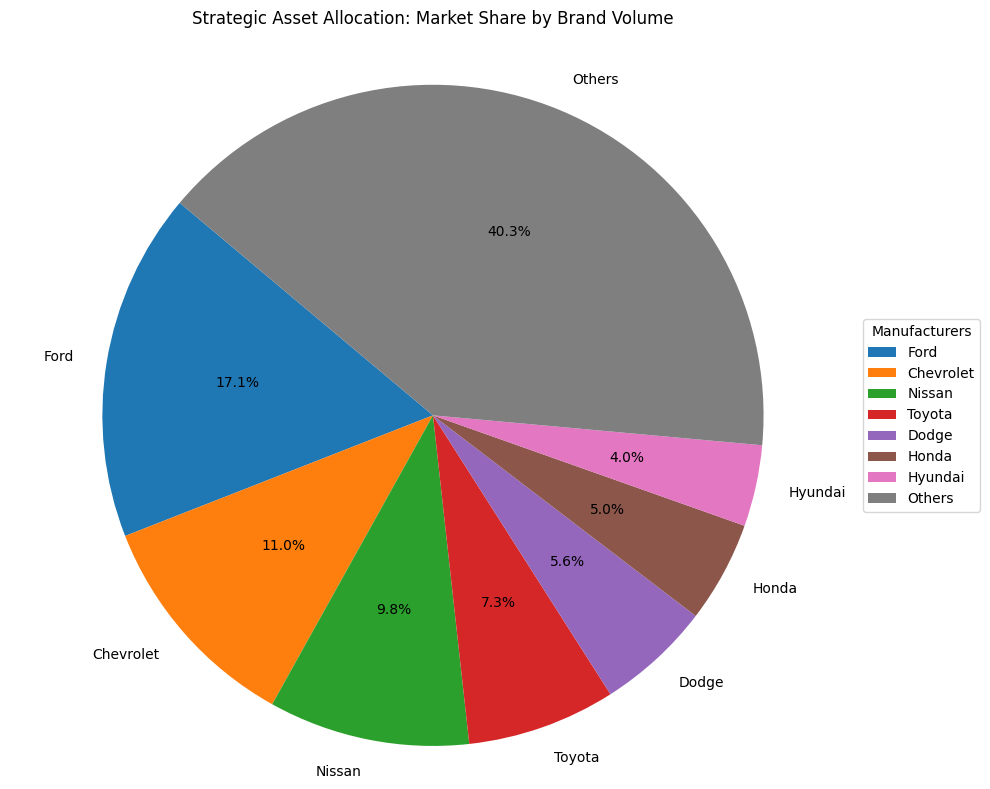

Task 7: Pie Chart completed. All 7 tasks in Window 1 are now finished.


In [ ]:
# DATA PREPROCESSING
# Aggregate brand volume; To prevent the pie chart from becoming unreadable with too many small slices; Taking the top 7 brands and grouping the rest as 'Others'
top_n = 7
brand_counts = df_car_sales['make'].value_counts()
top_brands = brand_counts.head(top_n)
others_count = brand_counts.iloc[top_n:].sum()

# Combine top brands with 'Others' category; Appending a new Series for 'Others'
plot_data = pd.concat([top_brands, pd.Series({'Others': others_count})])

logger.info(f"Market share data prepared. Top brand: {top_brands.index[0]} with {top_brands.iloc[0]} units.")

# Task 7: Pie Chart (Strategic Asset Allocation)
# Initialize the figure;
plt.figure(figsize=(10, 8))

# Create the Pie Chart; To visualize the "Strategic Asset Allocation" and identify "Safe Bet" brands; Using plt.pie with autopct for percentages and startangle for orientation
plt.pie(
    plot_data.values, 
    labels=plot_data.index, 
    autopct='%1.1f%%', 
    startangle=140,  
)

# Add MetaData
plt.title('Strategic Asset Allocation: Market Share by Brand Volume', pad=20)
plt.legend(title="Manufacturers", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

logger.info("Pie chart construction for Portfolio Risk completed.")

plt.axis('equal') # Set equal aspect ratio; To ensure the pie is drawn as a circle;
plt.tight_layout()
plt.show()
logger.info("Task 7: Pie Chart completed.")
